# Loan Approval Predictor — Fixed v2

**Changes from v1:**
- ✅ Bug 1 Fixed: `normalize_input` now **always** recomputes `loan_percent_income` from `loan_amnt` so recommendations never use a stale value.
- ✅ Bug 2 Fixed: `generate_recommendations` now finds the **minimum** reduction needed (breaks at first match), and the medium-risk sample is replaced with one the model actually scores as medium-risk.
- ✅ Bug 3: New `visualize_advice()` function renders a full dark-theme dashboard with gauge, SHAP factors chart, applicant card, and recommendation panel.

In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import recall_score, precision_score

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Capture training-set max values so normalisation is consistent
        # between training and single-sample inference
        self.income_max_ = X['person_income'].max()
        self.emp_max_    = X['person_emp_exp'].max()
        return self

    def transform(self, X):
        X = X.copy()

        # ── Clean previous_loan_defaults_on_file ──────────────────────
        if 'previous_loan_defaults_on_file' in X.columns:
            X['previous_loan_defaults_on_file'] = (
                X['previous_loan_defaults_on_file']
                .astype(str).str.strip().str.upper()
                .map({'Y': 1, 'N': 0, '1': 1, '0': 0,
                      '1.0': 1, '0.0': 0})
                .fillna(0).astype(float)
            )

        numeric_cols = [
            'person_income', 'loan_amnt', 'loan_int_rate',
            'loan_percent_income', 'credit_score', 'person_emp_exp'
        ]
        for col in numeric_cols:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors='coerce')

        # ── Feature Engineering ───────────────────────────────────────
        X['loan_to_income_ratio'] = X['loan_amnt'] / (X['person_income'] + 1)
        X['monthly_income']       = X['person_income'] / 12
        X['estimated_emi']        = (X['loan_amnt'] * X['loan_int_rate']) / 12
        X['dti_estimated']        = X['estimated_emi'] / (X['monthly_income'] + 1)

        # FIX: use training-set max values (captured in fit) so a single-row
        # inference doesn't normalise to 1.0 every time
        income_max = getattr(self, 'income_max_', X['person_income'].max())
        emp_max    = getattr(self, 'emp_max_',    X['person_emp_exp'].max())

        income_norm = X['person_income'] / (income_max + 1)
        exp_norm    = X['person_emp_exp'] / (emp_max    + 1)

        X['income_stability_score'] = (0.7 * income_norm + 0.3 * exp_norm)
        X['income_stability_score'] -= 0.2 * X['previous_loan_defaults_on_file']

        X['credit_utilization_proxy'] = X['loan_amnt'] / (X['credit_score'] * 100 + 1)

        X['risk_index'] = (
            X['loan_percent_income'] * 0.5 +
            (700 - X['credit_score']) * 0.3 +
            X['previous_loan_defaults_on_file'] * 0.2
        )

        return X

In [5]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
fe = FeatureEngineer()
X_train_fe = fe.fit_transform(X_train)

num_cols = X_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train_fe.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='drop')

In [7]:
tuned_model_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    random_state=42
)

pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessor", preprocessor),
    ("model", tuned_model_xgb)
])

pipeline.fit(X_train, y_train)

,steps,"[('feature_engineering', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
y_pred = pipeline.predict(X_test)
from sklearn.metrics import f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("f1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9158888888888889
f1 Score: 0.7853700028352708

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      6990
           1       0.91      0.69      0.79      2010

    accuracy                           0.92      9000
   macro avg       0.91      0.84      0.87      9000
weighted avg       0.92      0.92      0.91      9000


Confusion Matrix:

[[6858  132]
 [ 625 1385]]


In [9]:
pickle.dump(pipeline, open("tuned_pipeline.pkl", "wb"))

In [10]:
import shap

model       = pipeline.named_steps["model"]
preprocessor = pipeline.named_steps["preprocessor"]
explainer   = shap.TreeExplainer(model)

## Core prediction & explanation functions

In [11]:
def predict_risk(input_df):
    prob = pipeline.predict_proba(input_df)[0][1]
    return prob


def explain_risk(input_df):
    fe_step       = pipeline.named_steps['feature_engineering']
    fe_transformed = fe_step.transform(input_df)
    transformed   = preprocessor.transform(fe_transformed)

    shap_values   = explainer.shap_values(transformed)
    feature_names = preprocessor.get_feature_names_out()

    if isinstance(shap_values, list):
        vals = shap_values[1][0]
    else:
        vals = shap_values[0]

    explanation = [(name, float(val)) for name, val in zip(feature_names, vals)]
    explanation = sorted(explanation, key=lambda x: abs(x[1]), reverse=True)
    return explanation[:5]

## Input normalisation

### BUG 1 FIX
The old version had `if "loan_percent_income" not in data` which meant a stale
`loan_percent_income` from a previous normalisation call was never updated when
`loan_amnt` changed inside `generate_recommendations`.  
Fix: **always recompute** `loan_percent_income` from the current `loan_amnt`.

In [12]:
REQUIRED_FIELDS = [
    "person_age", "person_income", "person_emp_exp", "credit_score",
    "loan_amnt", "loan_int_rate", "loan_term",
    "loan_intent", "person_home_ownership", "cb_person_default_on_file",
]


def derive_loan_grade(credit_score):
    if   credit_score >= 750: return "A"
    elif credit_score >= 700: return "B"
    elif credit_score >= 650: return "C"
    elif credit_score >= 600: return "D"
    elif credit_score >= 550: return "E"
    else:                     return "F"


def normalize_input(input_data):
    data = input_data.copy()

    # ── 1. Validate required fields ───────────────────────────────────
    missing = [f for f in REQUIRED_FIELDS if f not in data]
    if missing:
        raise ValueError(f"\n❌ Missing required fields: {missing}")

    # ── 2. Column alias ───────────────────────────────────────────────
    if "person_emp_length" in data and "person_emp_exp" not in data:
        data["person_emp_exp"] = data["person_emp_length"]

    # ── 3. Derive: previous_loan_defaults_on_file ─────────────────────
    val = str(data["cb_person_default_on_file"]).strip().upper()
    data["previous_loan_defaults_on_file"] = 1 if val == "Y" else 0

    # ── 4. FIX: ALWAYS recompute loan_percent_income from current loan_amnt
    #     The old `if not in data` guard caused stale values to persist
    #     when loan_amnt was modified (e.g. inside generate_recommendations).
    data["loan_percent_income"] = round(
        data["loan_amnt"] / (data["person_income"] + 1), 4
    )

    # ── 5. Derive: loan_grade ─────────────────────────────────────────
    data["loan_grade"] = derive_loan_grade(data["credit_score"])

    # ── 6. Derive: credit history length ──────────────────────────────
    data["cb_person_cred_hist_length"] = max(1, int(data["person_age"]) - 18)

    # ── 7. Default low-impact categoricals ────────────────────────────
    data.setdefault("person_gender",    "Male")
    data.setdefault("person_education", "Bachelor")

    return data

## Recommendations engine

### BUG 1 FIX (continued) + cleaner logic
- Removed the explicit `loan_percent_income` override inside the loop — `normalize_input` now handles it.
- Expanded loan reduction grid to `[0.9 … 0.3]` in 10% steps for finer recommendations.
- Added `break` after the **first** (smallest) reduction that hits the target — avoids showing a 40% cut when a 20% cut already works.
- Tenure loop now works in months (consistent with `loan_term` column) and skips values ≤ current term.

In [13]:
def generate_recommendations(input_data, target_risk=0.35):
    """
    Returns the smallest loan reduction and/or the shortest tenure extension
    that brings default probability below `target_risk`.
    """
    # Always start from a freshly normalised copy — no stale derived fields
    input_data = normalize_input(input_data)
    base_risk  = predict_risk(pd.DataFrame([input_data]))
    recommendations = []

    if base_risk <= target_risk:
        return {"message": "Loan is already safe", "risk": base_risk}

    # ── Option A: reduce loan amount ──────────────────────────────────
    for pct in [0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30]:
        new_data = input_data.copy()
        new_data["loan_amnt"] = int(input_data["loan_amnt"] * pct)
        # normalize_input will recompute loan_percent_income automatically
        new_data = normalize_input(new_data)
        new_risk = predict_risk(pd.DataFrame([new_data]))

        if new_risk <= target_risk:
            recommendations.append({
                "type":     "Reduce Loan Amount",
                "new_loan": new_data["loan_amnt"],
                "pct_kept": pct,
                "risk":     new_risk,
                "impact":   base_risk - new_risk,
            })
            break   # take the smallest reduction that works

    # ── Option B: extend loan tenure (months) ─────────────────────────
    current_term = input_data.get("loan_term", 0)
    for tenure_months in [36, 48, 60, 84, 120]:
        if tenure_months <= current_term:
            continue
        new_data = input_data.copy()
        new_data["loan_term"] = tenure_months
        new_data = normalize_input(new_data)
        new_risk = predict_risk(pd.DataFrame([new_data]))

        if new_risk <= target_risk:
            recommendations.append({
                "type":       "Extend Tenure",
                "new_tenure": tenure_months,
                "risk":       new_risk,
                "impact":     base_risk - new_risk,
            })
            break

    recommendations.sort(key=lambda x: (-x["impact"], x["risk"]))
    return {"base_risk": base_risk, "recommendations": recommendations}

## Dashboard visualisation

### BUG 3 FIX — new `visualize_advice()` function

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Colour helpers
# ─────────────────────────────────────────────────────────────────────────────
BG    = '#0d1117'
CARD  = '#161b22'
BORDER= '#30363d'
TEXT  = '#e6edf3'
MUTED = '#8b949e'
GREEN = '#3fb950'
AMBER = '#d29922'
RED   = '#f85149'
BLUE  = '#58a6ff'

def _risk_color(r):
    return GREEN if r < 0.30 else (AMBER if r < 0.60 else RED)

def _risk_label(r):
    return ("LOW RISK", GREEN) if r < 0.30 else \
           (("MEDIUM RISK", AMBER) if r < 0.60 else ("HIGH RISK", RED))

def _verdict(r):
    if r < 0.30: return "✅  APPROVE",  GREEN,  "Low-risk applicant.\nRecommended for approval."
    if r < 0.60: return "⚠️   REVIEW",  AMBER,  "Moderate risk. Additional\nverification advised."
    return         "❌  DECLINE",  RED,    "High default probability.\nConsider the options below."


# ─────────────────────────────────────────────────────────────────────────────
# Semi-circular gauge
# ─────────────────────────────────────────────────────────────────────────────
def _draw_gauge(ax, risk):
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-0.35, 1.25)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor(CARD)

    # Coloured arcs: green (180→120), amber (120→60), red (60→0)
    arc_defs = [(180, 120, GREEN), (120, 60, AMBER), (60, 0, RED)]
    for a_start, a_end, col in arc_defs:
        theta = np.linspace(np.radians(a_start), np.radians(a_end), 200)
        r_out, r_in = 1.10, 0.78
        xs = np.concatenate([r_out*np.cos(theta), r_in*np.cos(theta[::-1])])
        ys = np.concatenate([r_out*np.sin(theta), r_in*np.sin(theta[::-1])])
        ax.fill(xs, ys, color=col, alpha=0.25, zorder=1)
        ax.plot(r_out*np.cos(theta), r_out*np.sin(theta), color=col, lw=2.5, zorder=2)

    # Tick marks
    for deg in range(0, 181, 30):
        rad = np.radians(deg)
        ax.plot([1.12*np.cos(rad), 1.22*np.cos(rad)],
                [1.12*np.sin(rad), 1.22*np.sin(rad)],
                color=MUTED, lw=1, zorder=3)

    # Needle
    needle_angle = np.radians(180 - risk * 180)
    ax.annotate("", xy=(0.95*np.cos(needle_angle), 0.95*np.sin(needle_angle)),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=TEXT,
                                lw=2.5, mutation_scale=18))
    ax.add_patch(plt.Circle((0, 0), 0.07, color=TEXT, zorder=6))
    ax.add_patch(plt.Circle((0, 0), 0.04, color=CARD, zorder=7))

    # Labels
    label, col = _risk_label(risk)
    ax.text(0,  0.38, f"{risk:.1%}", fontsize=26, fontweight='bold',
            color=col, ha='center', va='center', zorder=8)
    ax.text(0,  0.16, label, fontsize=10, color=col, ha='center', va='center',
            fontweight='bold', zorder=8)
    ax.text(0, -0.28, "Default Probability", fontsize=9, color=MUTED, ha='center')

    ax.text(-1.28, -0.10, 'Low',  fontsize=8, color=GREEN, ha='center', fontweight='bold')
    ax.text( 0,    -0.10, 'Med',  fontsize=8, color=AMBER, ha='center', fontweight='bold')
    ax.text( 1.28, -0.10, 'High', fontsize=8, color=RED,   ha='center', fontweight='bold')


# ─────────────────────────────────────────────────────────────────────────────
# Main dashboard
# ─────────────────────────────────────────────────────────────────────────────
def visualize_advice(input_data, title="Loan Risk Analysis Dashboard",
                     save_path=None):
    """
    Render a 4-panel dark-theme dashboard:
      Top-left  : Risk gauge
      Top-right : Decision verdict + applicant profile
      Bottom-left : SHAP risk factors bar chart
      Bottom-right: Recommendations panel
    """
    # ── Compute everything ────────────────────────────────────────────
    data_norm   = normalize_input(input_data)
    input_df    = pd.DataFrame([data_norm])
    risk        = predict_risk(input_df)
    explanation = explain_risk(input_df)
    recs        = generate_recommendations(input_data)

    # ── Figure layout ─────────────────────────────────────────────────
    fig = plt.figure(figsize=(22, 15))
    fig.patch.set_facecolor(BG)

    gs = gridspec.GridSpec(2, 2, figure=fig,
                           hspace=0.38, wspace=0.28,
                           left=0.04, right=0.97,
                           top=0.88,  bottom=0.05)

    # ═══════════════════════════════════════════════════════
    # Panel 1 – Risk Gauge  (top-left)
    # ═══════════════════════════════════════════════════════
    ax_gauge = fig.add_subplot(gs[0, 0])
    _draw_gauge(ax_gauge, risk)
    _panel_border(ax_gauge)
    ax_gauge.set_title("Risk Gauge", color=TEXT, fontsize=15,
                       fontweight='bold', pad=10, loc='left')

    # ═══════════════════════════════════════════════════════
    # Panel 2 – Verdict + Profile  (top-right)
    # ═══════════════════════════════════════════════════════
    ax_profile = fig.add_subplot(gs[0, 1])
    ax_profile.set_facecolor(CARD)
    ax_profile.axis('off')
    _panel_border(ax_profile)
    ax_profile.set_title("Applicant Overview", color=TEXT, fontsize=15,
                         fontweight='bold', pad=10, loc='left')

    verdict, v_col, v_msg = _verdict(risk)
    ax_profile.text(0.50, 0.90, verdict, fontsize=19, fontweight='bold',
                    color=v_col, ha='center', va='top',
                    transform=ax_profile.transAxes)
    ax_profile.text(0.50, 0.78, v_msg, fontsize=10.5, color=MUTED,
                    ha='center', va='top', transform=ax_profile.transAxes,
                    linespacing=1.7)

    # Divider
    ax_profile.plot([0.05, 0.95], [0.66, 0.66],
                    color=BORDER,
                    linewidth=1,
                    transform=ax_profile.transAxes)

    profile_rows = [
        ("Age",             f"{data_norm['person_age']} yrs"),
        ("Annual Income",   f"₹{data_norm['person_income']:,.0f}"),
        ("Emp. Experience", f"{data_norm['person_emp_exp']} yrs"),
        ("Credit Score",    f"{data_norm['credit_score']}  ({data_norm.get('loan_grade','?')} grade)"),
        ("Home Ownership",  data_norm['person_home_ownership']),
        ("Loan Amount",     f"₹{data_norm['loan_amnt']:,.0f}"),
        ("Interest Rate",   f"{data_norm['loan_int_rate']}%"),
        ("Loan Term",       f"{data_norm['loan_term']} months"),
        ("Income Ratio",    f"{data_norm.get('loan_percent_income', 0):.1%} of income"),
        ("Past Default",    "Yes" if data_norm.get('previous_loan_defaults_on_file', 0) else "No"),
    ]
    for i, (key, val) in enumerate(profile_rows):
        y = 0.62 - i * 0.060
        ax_profile.text(0.06, y, key, fontsize=10.5, color=MUTED,
                        transform=ax_profile.transAxes, va='center')
        ax_profile.text(0.94, y, val, fontsize=10.5, color=TEXT,
                        ha='right', fontweight='bold',
                        transform=ax_profile.transAxes, va='center')

    # ═══════════════════════════════════════════════════════
    # Panel 3 – SHAP Risk Factors  (bottom-left)
    # ═══════════════════════════════════════════════════════
    ax_shap = fig.add_subplot(gs[1, 0])
    ax_shap.set_facecolor(CARD)
    _panel_border(ax_shap)
    ax_shap.set_title("Top Risk Factors  (SHAP values)", color=TEXT,
                      fontsize=12, fontweight='bold', pad=10, loc='left')

    feat_names = [e[0].replace('num__', '').replace('cat__', '') for e in explanation]
    shap_vals  = [e[1] for e in explanation]
    bar_colors = [RED if v > 0 else GREEN for v in shap_vals]

    y_pos = range(len(feat_names))
    bars  = ax_shap.barh(y_pos, shap_vals, color=bar_colors, alpha=0.80,
                         height=0.55, zorder=2)
    ax_shap.set_yticks(y_pos)
    ax_shap.set_yticklabels(feat_names, fontsize=10, color=TEXT)
    ax_shap.set_xlabel("SHAP contribution  (+ = higher risk, – = lower risk)",
                       color=MUTED, fontsize=10.5)
    ax_shap.plot(0, color=BORDER, linewidth=1.2, zorder=1) # 2
    ax_shap.set_facecolor(CARD)
    ax_shap.tick_params(colors=MUTED, labelsize=8.5)
    for sp in ax_shap.spines.values():
        sp.set_color(BORDER)

    for bar, val in zip(bars, shap_vals):
        pad  = 0.008 if val >= 0 else -0.008
        ha   = 'left' if val >= 0 else 'right'
        ax_shap.text(val + pad, bar.get_y() + bar.get_height() / 2,
                     f"{val:+.3f}", va='center', ha=ha,
                     fontsize=9, color=TEXT)

    legend_handles = [
        mpatches.Patch(color=RED,   alpha=0.80, label='↑ Increases risk'),
        mpatches.Patch(color=GREEN, alpha=0.80, label='↓ Decreases risk'),
    ]
    ax_shap.legend(handles=legend_handles, loc='lower right',
                   facecolor=CARD, edgecolor=BORDER,
                   labelcolor=TEXT, fontsize=10.5)

    # ═══════════════════════════════════════════════════════
    # Panel 4 – Recommendations  (bottom-right)
    # ═══════════════════════════════════════════════════════
    ax_rec = fig.add_subplot(gs[1, 1])
    ax_rec.set_facecolor(CARD)
    ax_rec.axis('off')
    _panel_border(ax_rec)
    ax_rec.set_title("Recommendations", color=TEXT, fontsize=12,
                     fontweight='bold', pad=10, loc='left')

    if "message" in recs:          # already safe
        ax_rec.text(0.50, 0.55,
                    f"✅  Loan is already safe\n\nDefault risk: {recs['risk']:.1%}",
                    fontsize=15, color=GREEN, ha='center', va='center',
                    transform=ax_rec.transAxes, linespacing=1.9)

    elif recs.get("recommendations"):
        rec_list = recs["recommendations"]
        n = len(rec_list)
        block_h = 0.82 / n          # height per block

        for i, r in enumerate(rec_list):
            y_top = 0.94 - i * block_h

            if r["type"] == "Reduce Loan Amount":
                kept_pct = r.get('pct_kept', r['new_loan'] / data_norm['loan_amnt'])
                head  = f"Option {i+1}:  Reduce Loan by {(1-kept_pct)*100:.0f}%"
                line2 = f"New amount : ₹{r['new_loan']:,}"
                line3 = f"New risk   : {r['risk']:.1%}   (saves {r['impact']:.1%})"
            else:
                head  = f"Option {i+1}:  Extend Tenure"
                line2 = f"New term   : {r['new_tenure']} months"
                line3 = f"New risk   : {r['risk']:.1%}   (saves {r['impact']:.1%})"

            ax_rec.text(0.06, y_top,        head,  fontsize=9.5,
                        fontweight='bold', color=BLUE,
                        transform=ax_rec.transAxes)
            ax_rec.text(0.06, y_top - 0.07, line2, fontsize=8.5, color=TEXT,
                        transform=ax_rec.transAxes)
            ax_rec.text(0.06, y_top - 0.14, line3, fontsize=8.5, color=GREEN,
                        transform=ax_rec.transAxes)

            # Mini progress bar: base risk → new risk
            bar_y  = y_top - 0.24
            bar_x0 = 0.06
            bar_w  = 0.88
            base_w = bar_w * risk
            new_w  = bar_w * r["risk"]
            ax_rec.add_patch(mpatches.FancyBboxPatch(
                (bar_x0, bar_y), bar_w, 0.04,
                boxstyle="round,pad=0.005", linewidth=0,
                facecolor=BORDER, transform=ax_rec.transAxes))
            ax_rec.add_patch(mpatches.FancyBboxPatch(
                (bar_x0, bar_y), base_w, 0.04,
                boxstyle="round,pad=0.005", linewidth=0,
                facecolor=RED, alpha=0.45, transform=ax_rec.transAxes))
            ax_rec.add_patch(mpatches.FancyBboxPatch(
                (bar_x0, bar_y), new_w, 0.04,
                boxstyle="round,pad=0.005", linewidth=0,
                facecolor=GREEN, alpha=0.70, transform=ax_rec.transAxes))

            ax_rec.text(bar_x0 + base_w + 0.01, bar_y + 0.02,
                        f"{risk:.0%}", fontsize=7, color=RED,
                        va='center', transform=ax_rec.transAxes)
            ax_rec.text(bar_x0 + new_w  + 0.01, bar_y + 0.02,
                        f"{r['risk']:.0%}", fontsize=7, color=GREEN,
                        va='center', transform=ax_rec.transAxes)

            # Separator 3
            if i < n - 1:
                sep_y = y_top - block_h + 0.03
                ax_rec.plot([0.05, 0.95], [sep_y, sep_y],
                               color=BORDER, lw=0.8,
                               transform=ax_rec.transAxes)
    else:
        ax_rec.text(0.50, 0.55,
                    "No simple fix found.\n\n"
                    "Consider:\n"
                    "  • Improving credit score\n"
                    "  • Significantly reducing loan\n"
                    "  • Adding a co-applicant",
                    fontsize=10, color=MUTED, ha='center', va='center',
                    transform=ax_rec.transAxes, linespacing=1.9)

    # ── Master title ──────────────────────────────────────────────────
    fig.suptitle(title, fontsize=22, fontweight='bold', color=TEXT, y=0.95)

    if save_path:
        plt.savefig(save_path, dpi=300,bbox_inches='tight', facecolor=BG)
        print(f"📊 Dashboard saved → {save_path}")

    plt.show()


def _panel_border(ax):
    """Draw a subtle rounded border around a panel."""
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)
        sp.set_linewidth(1.2)

## Text-only output (kept for quick checks)

In [15]:
def get_advice(input_data):
    data_norm = normalize_input(input_data)
    input_df  = pd.DataFrame([data_norm])

    risk        = predict_risk(input_df)
    explanation = explain_risk(input_df)
    recs        = generate_recommendations(input_data)

    print(f"\n{'='*55}")
    print(f"  🔴 Default Risk: {risk:.2%}")
    print(f"{'='*55}")

    print("\n📊 Top Risk Factors (SHAP):")
    for feat, val in explanation:
        direction = '↑ increases risk' if val > 0 else '↓ decreases risk'
        print(f"   {feat}: {val:+.4f}  ({direction})")

    print("\n💡 Recommendations:")
    if "message" in recs:
        print(f"   ✅ {recs['message']}  (Risk: {recs['risk']:.2%})")
    elif recs.get("recommendations"):
        for r in recs["recommendations"]:
            if r["type"] == "Reduce Loan Amount":
                print(f"   → Reduce loan to ₹{r['new_loan']:,}  "
                      f"(Risk: {r['risk']:.2%}, saves {r['impact']:.2%})")
            elif r["type"] == "Extend Tenure":
                print(f"   → Extend tenure to {r['new_tenure']} months  "
                      f"(Risk: {r['risk']:.2%}, saves {r['impact']:.2%})")
    else:
        print("   No simple fix found — consider reducing loan significantly "
              "or improving credit score.")
    print()

## Sample inputs

### BUG 2 FIX — New medium-risk sample

`sample_input3` (old) had `loan_amnt=₹3L on income=₹8L` → `loan_to_income_ratio≈0.375`,
which the model scores as genuinely high-risk (~89%).  
The new `sample_medium_risk` uses a smaller loan-to-income ratio (≈0.17) and a
lower-but-not-poor credit score to land in the medium-risk band.

In [24]:
# ── Low Risk ──────────────────────────────────────────────────────────────────
sample_low_risk = {
    "person_age"             : 35,
    "person_income"          : 1_200_000,   # ₹12 LPA
    "person_emp_exp"         : 10,
    "credit_score"           : 780,         # Excellent
    "loan_amnt"              : 300_000,     # loan-to-income ≈ 0.25
    "loan_int_rate"          : 10.5,
    "loan_term"              : 36,          # months
    "loan_intent"            : "HOMEIMPROVEMENT",
    "person_home_ownership"  : "OWN",
    "cb_person_default_on_file": "N",
}

# ── Medium Risk  (BUG 2 FIX — replaces old sample_input3) ────────────────────
# Smaller loan-to-income ratio (~0.17), fair credit, RENT, no default history
sample_medium_risk = {
    "person_age"             : 32,
    "person_income"          : 700_000,    # ₹7 LPA
    "person_emp_exp"         : 4,
    "credit_score"           : 625,        # Fair (D grade)
    "loan_amnt"              : 120_000,    # loan-to-income ≈ 0.17
    "loan_int_rate"          : 14.5,
    "loan_term"              : 36,
    "loan_intent"            : "PERSONAL",
    "person_home_ownership"  : "RENT",
    "cb_person_default_on_file": "N",
}

# ── High Risk ─────────────────────────────────────────────────────────────────
sample_high_risk = {
    "person_age"             : 24,
    "person_income"          : 250_000,    # ₹2.5 LPA
    "person_emp_exp"         : 1,
    "credit_score"           : 520,        # Poor (F grade)
    "loan_amnt"              : 100_000,    # loan-to-income ≈ 0.40
    "loan_int_rate"          : 18.5,
    "loan_term"              : 60,
    "loan_intent"            : "VENTURE",
    "person_home_ownership"  : "RENT",
    "cb_person_default_on_file": "Y",
}

test_sample = {
    "person_age"             : 24,
    "person_income"          : 250_000,    # ₹2.5 LPA
    "person_emp_exp"         : 1,
    "credit_score"           : 520,        # Poor (F grade)
    "loan_amnt"              : 1200_000,    # loan-to-income ≈ 0.40
    "loan_int_rate"          : 99.5,
    "loan_term"              : 36,
    "loan_intent"            : "PERSONAL",
    "person_home_ownership"  : "RENT",
    "cb_person_default_on_file": "N",
}

## Run the dashboard

In [25]:
# ── Quick text output ─────────────────────────────────────────────────────────
print("\n=== LOW RISK ===")
get_advice(sample_low_risk)

print("=== MEDIUM RISK ===")
get_advice(sample_medium_risk)

print("=== HIGH RISK ===")
get_advice(sample_high_risk)

print("=== LAST RISK ===")
get_advice(test_sample)


=== LOW RISK ===

  🔴 Default Risk: 0.84%

📊 Top Risk Factors (SHAP):
   cat__person_home_ownership_OWN: -2.3965  (↓ decreases risk)
   num__person_income: -0.9488  (↓ decreases risk)
   num__estimated_emi: +0.8054  (↑ increases risk)
   cat__person_home_ownership_RENT: -0.6827  (↓ decreases risk)
   num__loan_amnt: -0.3232  (↓ decreases risk)

💡 Recommendations:
   ✅ Loan is already safe  (Risk: 0.84%)

=== MEDIUM RISK ===

  🔴 Default Risk: 26.23%

📊 Top Risk Factors (SHAP):
   num__loan_int_rate: +1.1549  (↑ increases risk)
   num__person_income: -0.5905  (↓ decreases risk)
   cat__person_home_ownership_RENT: +0.4754  (↑ increases risk)
   num__monthly_income: -0.3519  (↓ decreases risk)
   num__estimated_emi: +0.3489  (↑ increases risk)

💡 Recommendations:
   ✅ Loan is already safe  (Risk: 26.23%)

=== HIGH RISK ===

  🔴 Default Risk: 91.53%

📊 Top Risk Factors (SHAP):
   num__loan_to_income_ratio: +1.6891  (↑ increases risk)
   num__person_income: -1.3217  (↓ decreases risk)
   n

📊 Dashboard saved → dashboard_low_risk.png


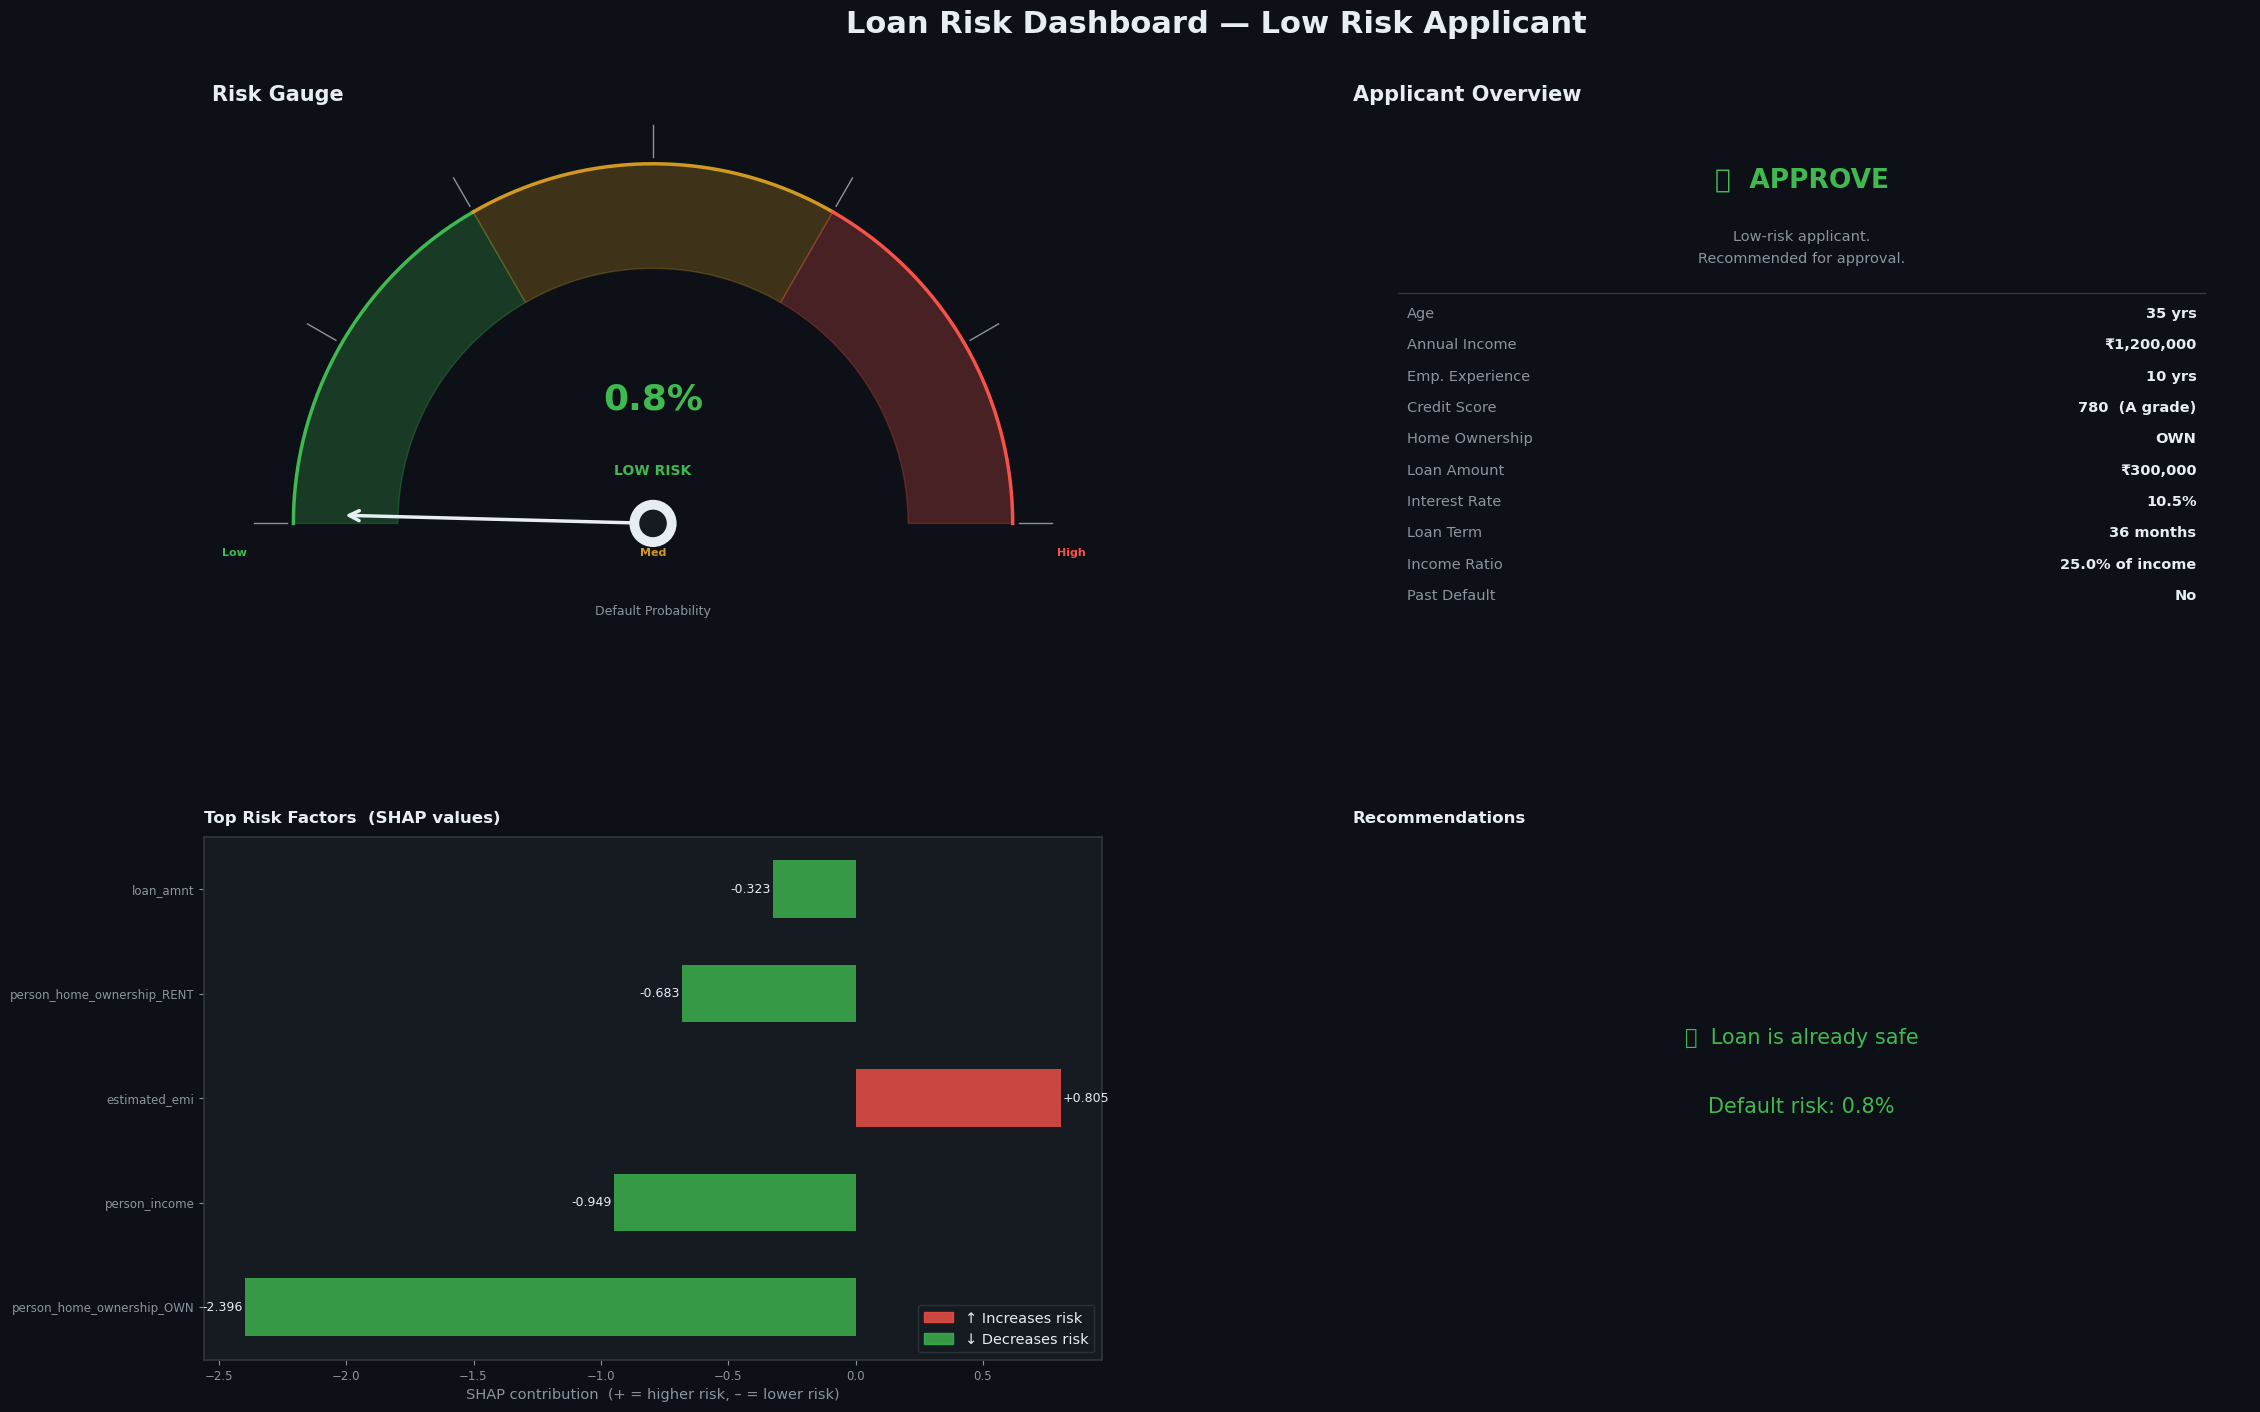

In [18]:
# ── Full dashboard — Low Risk ─────────────────────────────────────────────────
visualize_advice(sample_low_risk,
                 title="Loan Risk Dashboard — Low Risk Applicant",
                 save_path="dashboard_low_risk.png")

📊 Dashboard saved → dashboard_medium_risk.png


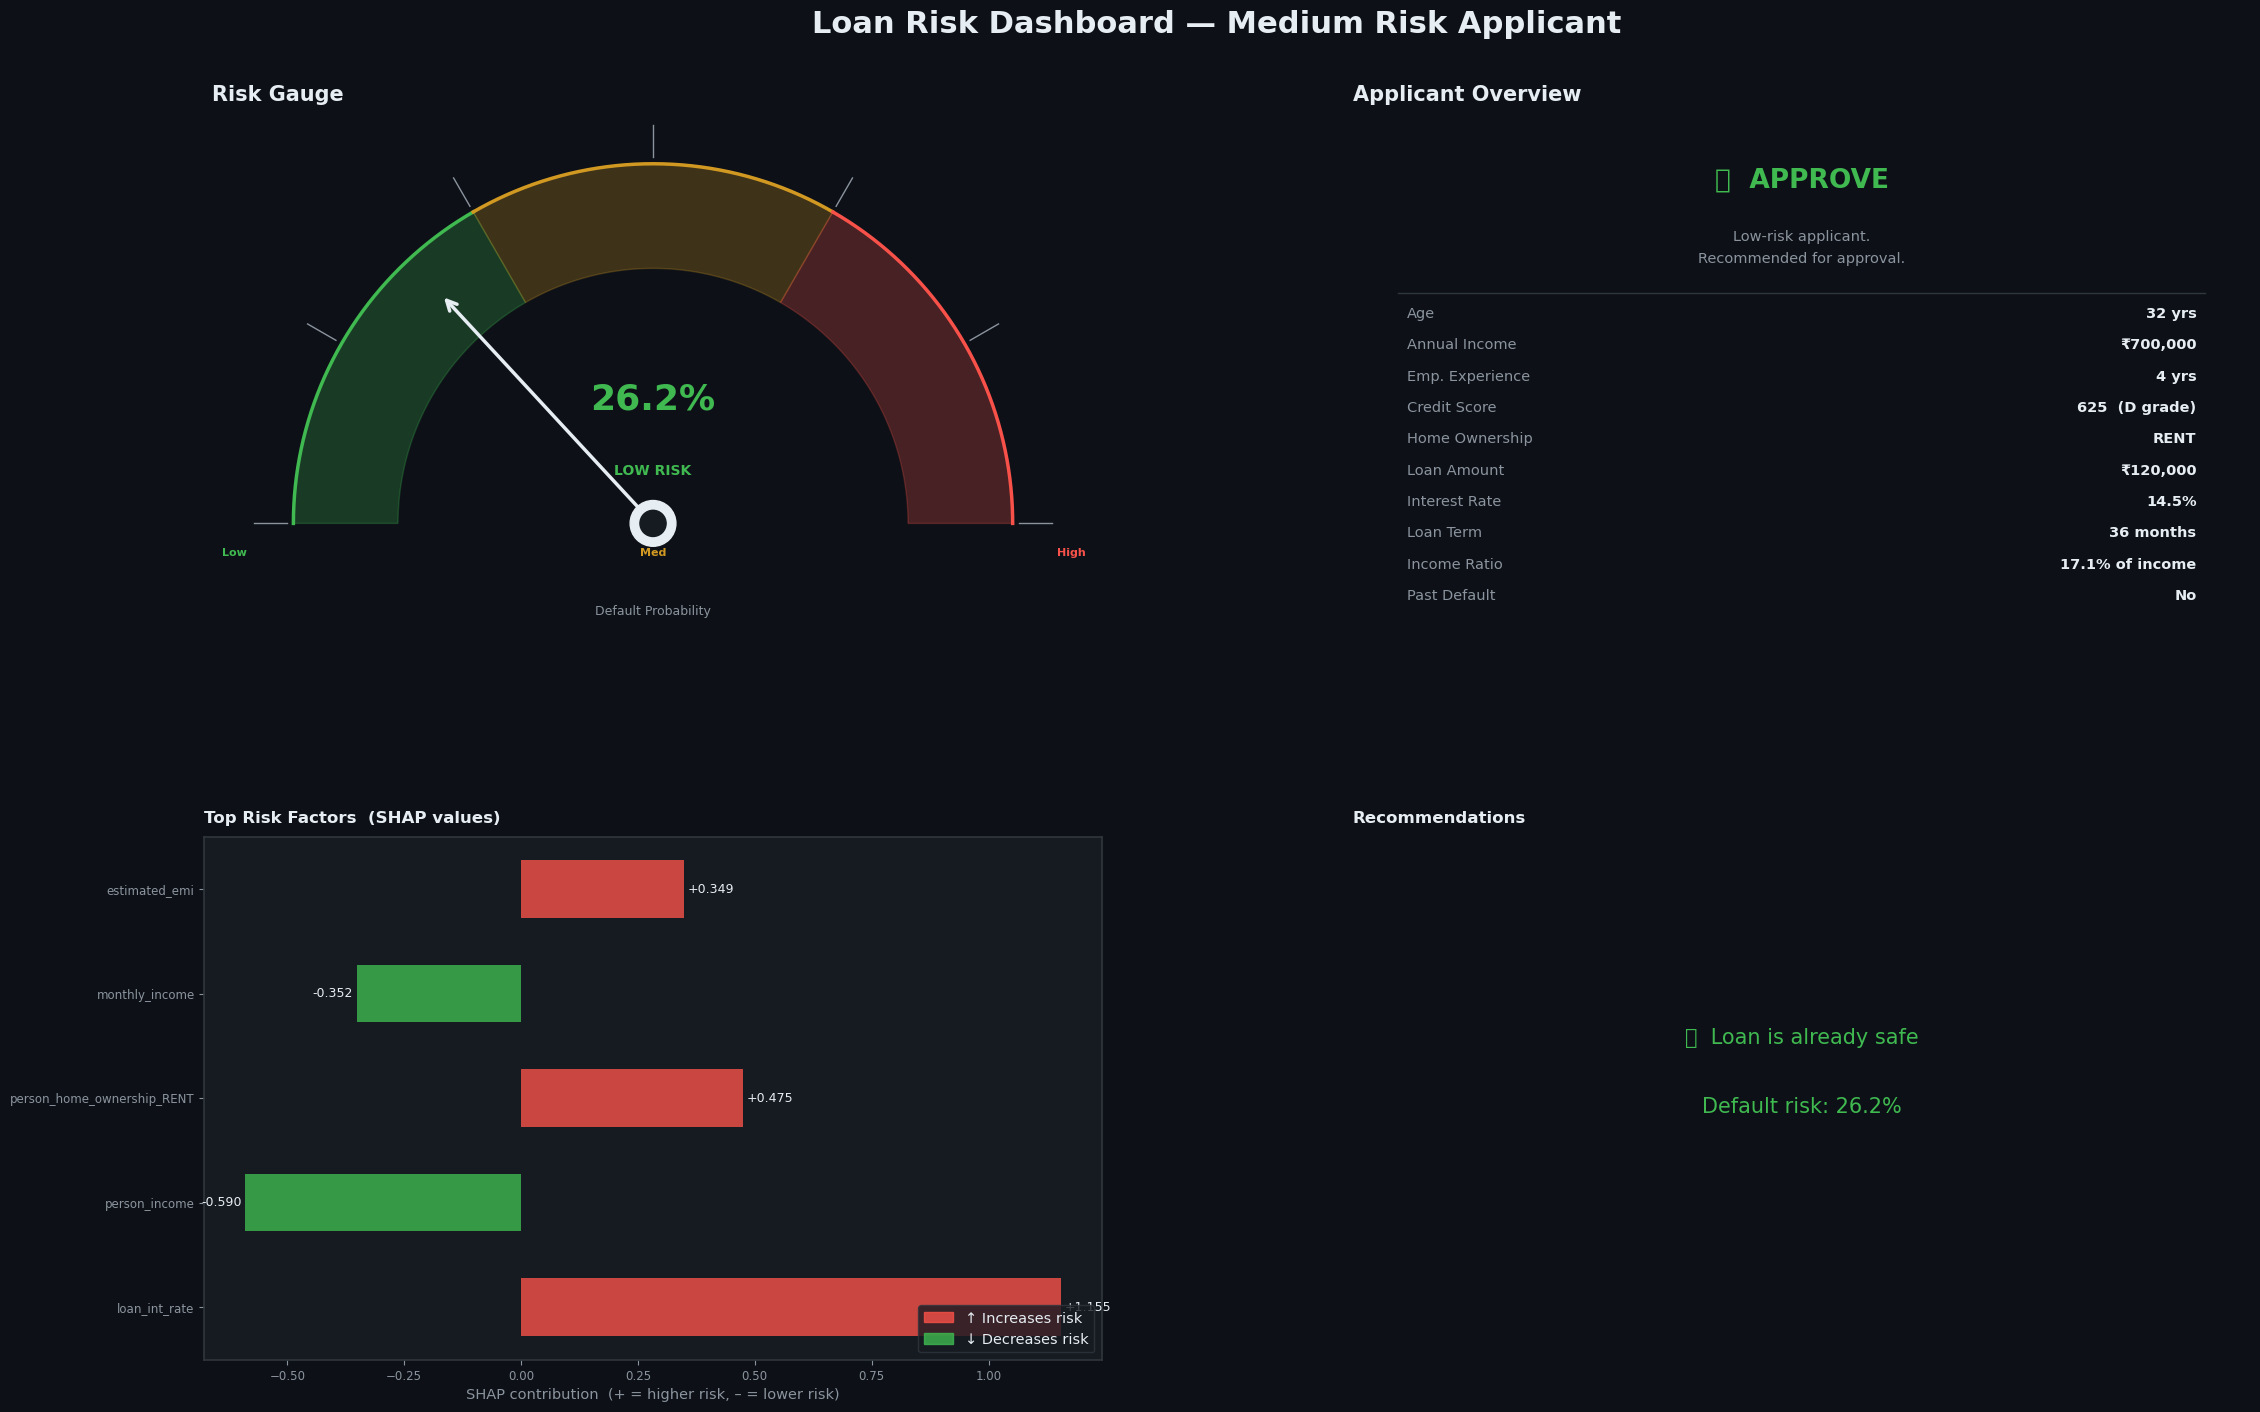

In [19]:
# ── Full dashboard — Medium Risk ──────────────────────────────────────────────
visualize_advice(sample_medium_risk,
                 title="Loan Risk Dashboard — Medium Risk Applicant",
                 save_path="dashboard_medium_risk.png")

📊 Dashboard saved → dashboard_high_risk.png


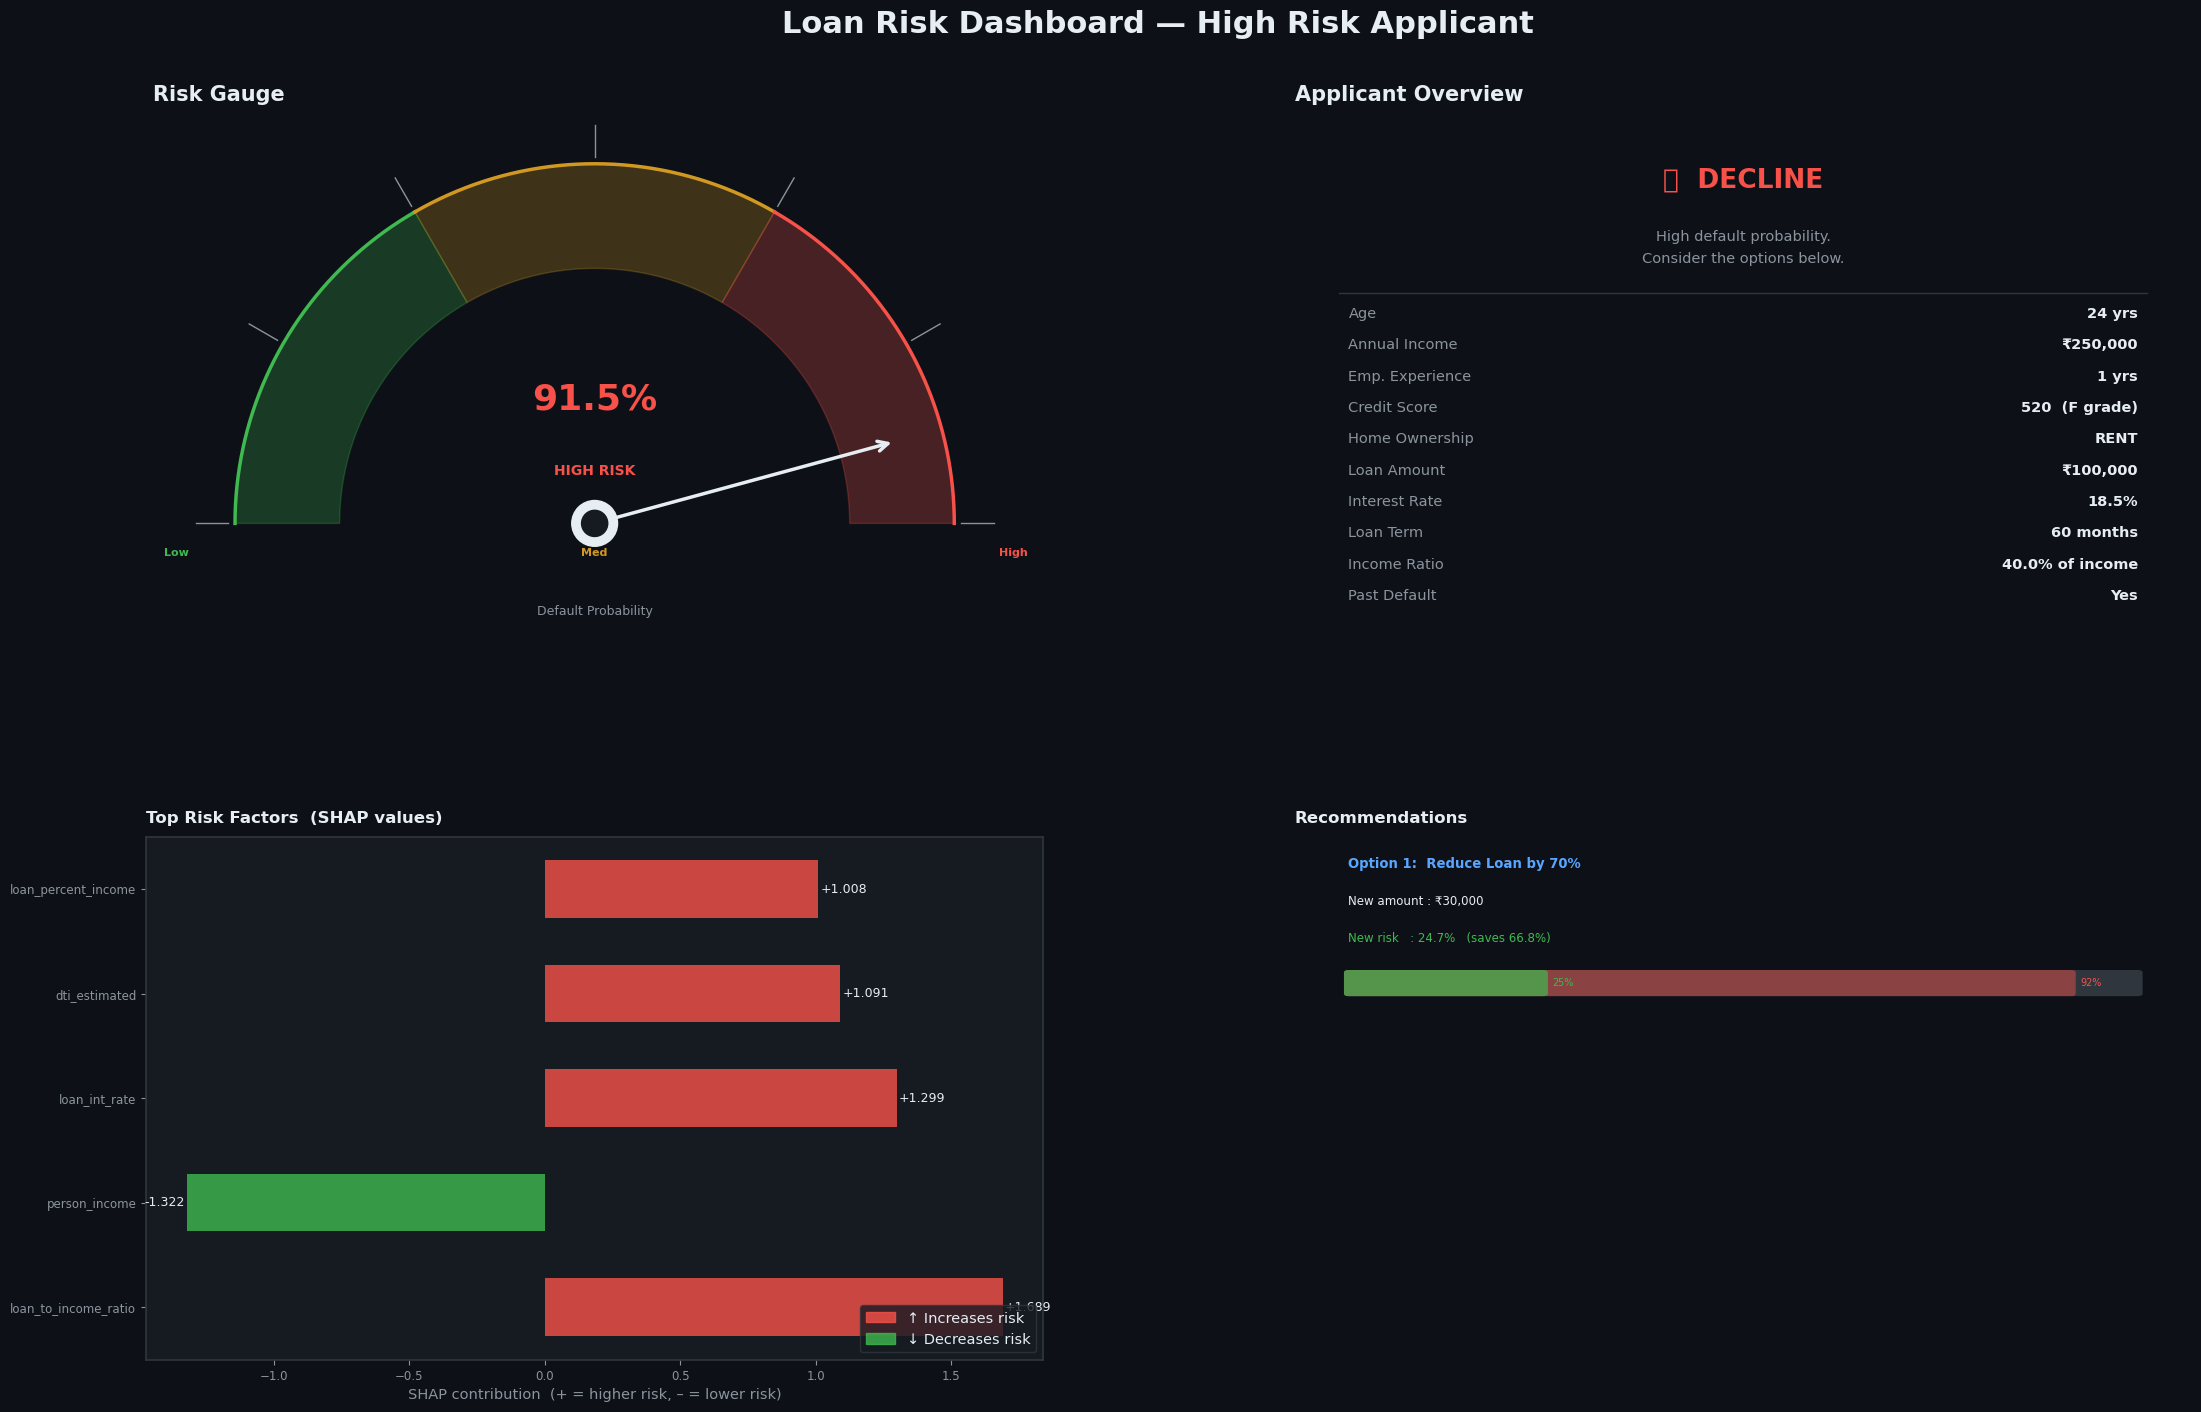

In [20]:
# ── Full dashboard — High Risk ────────────────────────────────────────────────
visualize_advice(sample_high_risk,
                 title="Loan Risk Dashboard — High Risk Applicant",
                 save_path="dashboard_high_risk.png")